In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from itertools import combinations
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Load data
df = pd.read_csv("train.csv")

In [3]:
df["price"].min(), df["price"].max()

(100000, 1660000000)

In [4]:
# normalize price
df["price"] = df["price"] / 100000

In [5]:
df["price"].describe()

count    306226.000000
mean        523.414622
std         913.719573
min           1.000000
25%          99.000000
50%         205.000000
75%         590.000000
max       16600.000000
Name: price, dtype: float64

In [6]:
np.log1p(df["price"]).describe()

count    306226.000000
mean          5.469862
std           1.260347
min           0.693147
25%           4.605170
50%           5.327876
75%           6.381816
max           9.717218
Name: price, dtype: float64

In [7]:
def plot_histogram_boxplot(
    data,
    field_name="Value",
    bins=50,
    figsize=(10, 6),
    hist_ratio=4,
    box_ratio=1,
    hspace=0.3,
):
    data = pd.Series(data).dropna()

    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": [hist_ratio, box_ratio]},
    )

    xmin, xmax = data.min(), data.max()

    axes[0].hist(data, bins=bins)
    axes[0].set_xlim(xmin, xmax)
    axes[0].set_title(f"Histogram of {field_name}")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].boxplot(data, vert=False)
    axes[1].set_xlim(xmin, xmax)
    axes[1].set_title(f"Box Plot of {field_name}")
    axes[1].set_xlabel(field_name)
    axes[1].grid(axis="x", alpha=0.3)

    fig.subplots_adjust(hspace=hspace, bottom=0.15)

    plt.show()

In [9]:
def remove_iqr_outliers(
    data,
    multiplier=1.5,
    remove_lower=False,
    verbose=True,
):
    data = pd.Series(data).dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    if verbose:
        print(f"Lower bound : {lower_bound:,.2f}")
        print(f"Upper bound : {upper_bound:,.2f}")

    if remove_lower:
        return data[(data >= lower_bound) & (data <= upper_bound)]

    return data[data <= upper_bound]

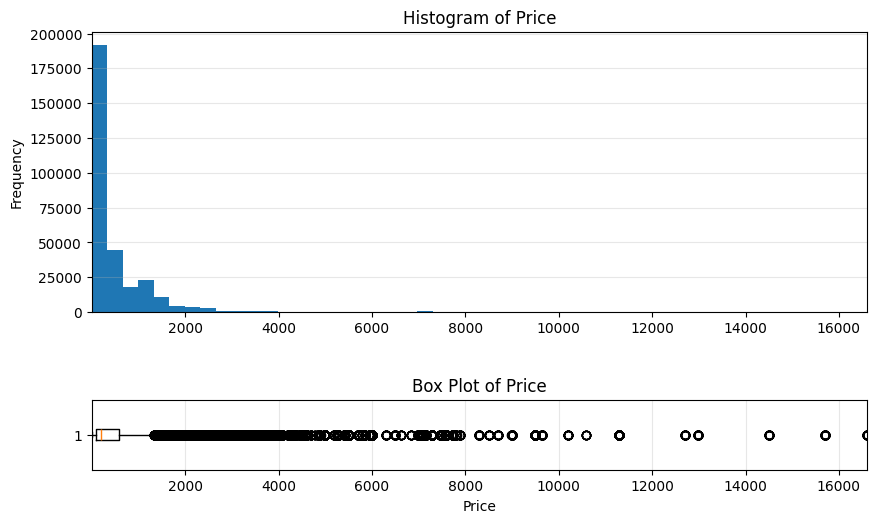

In [8]:
plot_histogram_boxplot(df["price"], "Price", hspace=0.5)

Lower bound : -637.50
Upper bound : 1,326.50


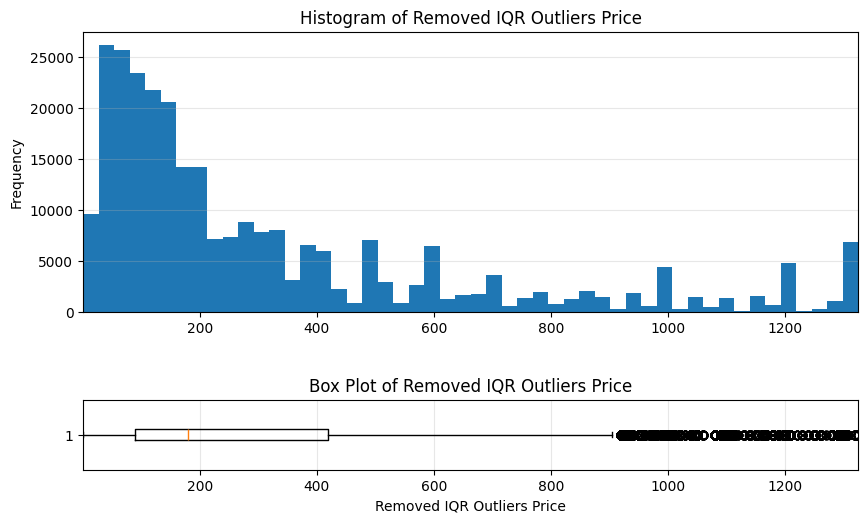

In [10]:
plot_histogram_boxplot(remove_iqr_outliers(df["price"]), "Removed IQR Outliers Price", hspace=0.5)

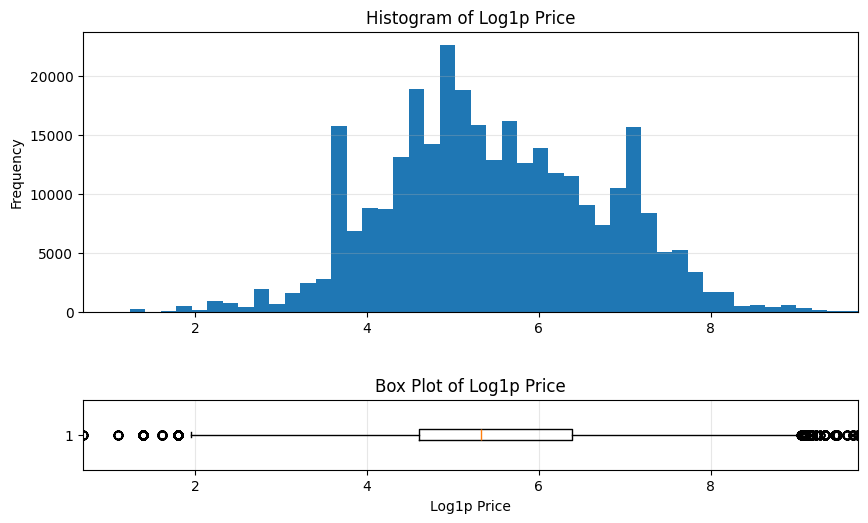

In [11]:
plot_histogram_boxplot(np.log1p(df["price"]), "Log1p Price", hspace=0.5)

Lower bound : -637.50
Upper bound : 1,326.50


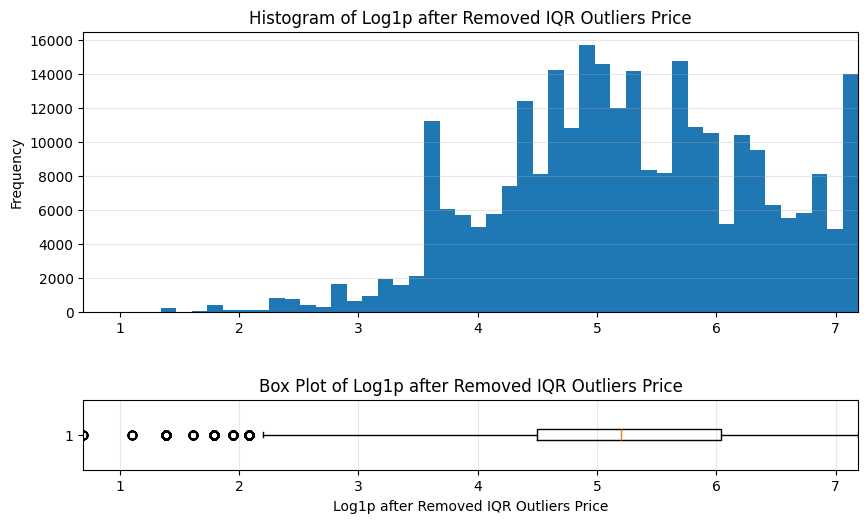

In [12]:
plot_histogram_boxplot(np.log1p(remove_iqr_outliers(df["price"])), "Log1p after Removed IQR Outliers Price", hspace=0.5)

Lower bound : 1.94
Upper bound : 9.05


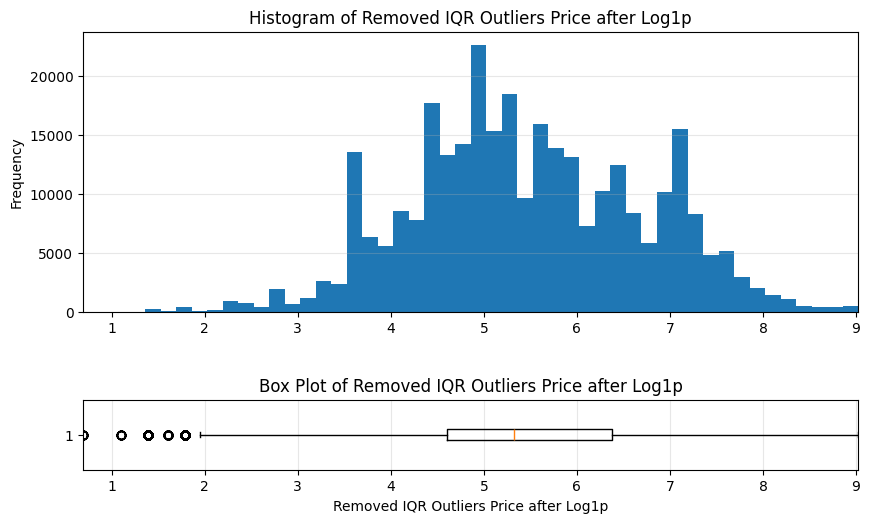

In [13]:
plot_histogram_boxplot(remove_iqr_outliers(np.log1p(df["price"])), "Removed IQR Outliers Price after Log1p", hspace=0.5)